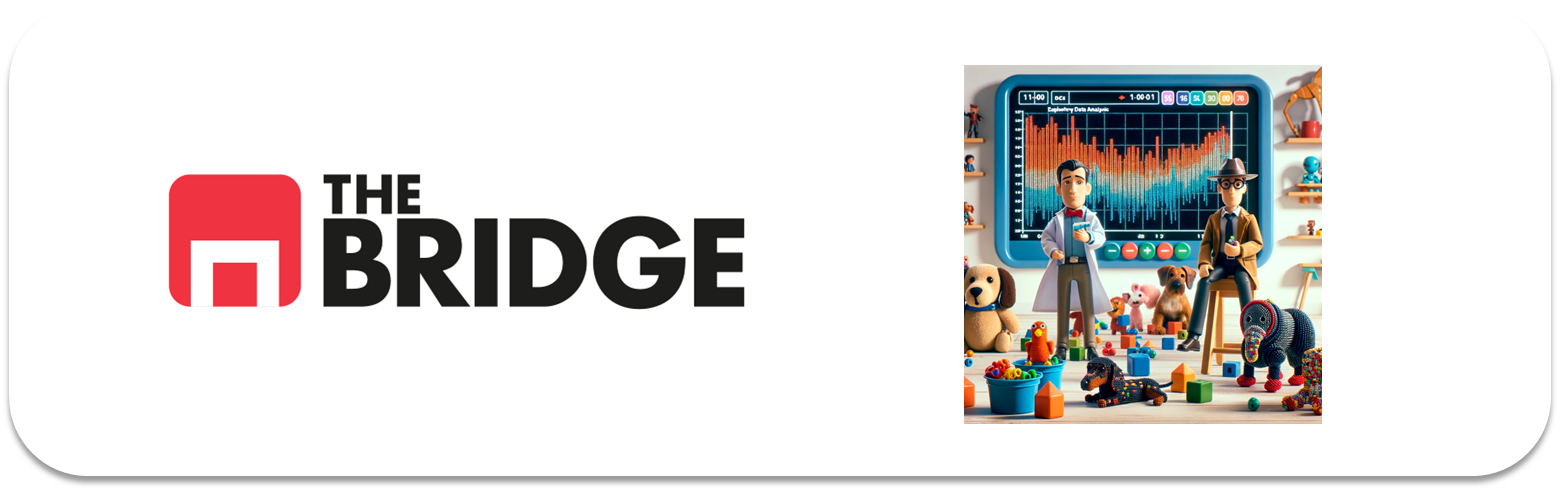

## PRACTICA OBLIGATORIA: **Análisis Multivariante**

* La práctica obligatoria de esta unidad consiste en completar el análisis del dataset del Titanic, dirigido por una serie de preguntas, y de terminar de analizar algunos aspectos del dataset de viajes. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0


Importa los paquetes y módulos que necesites a lo largo del notebook

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


## #1: Titanic

### #1.1

Carga en un dataframe el dataset del titanic, que está en la ruta "./data/titanic.csv".

In [3]:
df_titanic = pd.read_csv("./data/titanic.csv")
df_titanic

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


### #1.2

Deshazte de las columnas "deck", "survived", "pclass" y "embarked" porque no las emplearemos, la primera por su cantidad de nulos y el resto porque son variantes de otras que ya existen y cuyos valores resultan más expresivos a la hora de hacer un análisis. 

In [4]:
df = df_titanic.copy()

In [5]:
df = df.drop(columns = ["deck", "survived", "pclass", "embarked"])

In [6]:
df

,sex,age,sibsp,parch,fare,class,who,adult_male,embark_town,alive,alone
0,male,22.0,1,0,7.2500,Third,man,True,Southampton,no,False
1,female,38.0,1,0,71.2833,First,woman,False,Cherbourg,yes,False
2,female,26.0,0,0,7.9250,Third,woman,False,Southampton,yes,True
3,female,35.0,1,0,53.1000,First,woman,False,Southampton,yes,False
4,male,35.0,0,0,8.0500,Third,man,True,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...
886,male,27.0,0,0,13.0000,Second,man,True,Southampton,no,True
887,female,19.0,0,0,30.0000,First,woman,False,Southampton,yes,True
888,female,NaN,1,2,23.4500,Third,woman,False,Southampton,no,False
889,male,26.0,0,0,30.0000,First,man,True,Cherbourg,yes,True


### #1.3

Suma las columnas "parch" y "sibsp" para tener el número de parientes de cada pasajero, guarda el resultado en otra columna "family_members", luego deshazte de "parch" y "sibsp"

In [7]:
df["family_members"] = df["parch"] + df["sibsp"]

In [8]:
df = df.drop(columns = ["parch", "sibsp"])

In [9]:
df

,sex,age,fare,class,who,adult_male,embark_town,alive,alone,family_members
0,male,22.0,7.2500,Third,man,True,Southampton,no,False,1
1,female,38.0,71.2833,First,woman,False,Cherbourg,yes,False,1
2,female,26.0,7.9250,Third,woman,False,Southampton,yes,True,0
3,female,35.0,53.1000,First,woman,False,Southampton,yes,False,1
4,male,35.0,8.0500,Third,man,True,Southampton,no,True,0
...,...,...,...,...,...,...,...,...,...,...
886,male,27.0,13.0000,Second,man,True,Southampton,no,True,0
887,female,19.0,30.0000,First,woman,False,Southampton,yes,True,0
888,female,NaN,23.4500,Third,woman,False,Southampton,no,False,3
889,male,26.0,30.0000,First,man,True,Cherbourg,yes,True,0


### #1.4

Imputa la moda a los valores nulos de "embark_town"

In [13]:
df.isnull().sum()

sex                 0
age               177
fare                0
class               0
who                 0
adult_male          0
embark_town         2
alive               0
alone               0
family_members      0
dtype: int64

In [14]:
df["embark_town"] = df["embark_town"].fillna(df["embark_town"].mode()[0])

In [15]:
df.isnull().sum()


sex                 0
age               177
fare                0
class               0
who                 0
adult_male          0
embark_town         0
alive               0
alone               0
family_members      0
dtype: int64

### #1.5

Imputa la media a los valores faltantes de "age", si quieres puedes hacer algo más preciso (por ejemplo considerando además la columna "who")

In [16]:
df["age"] = df["age"].fillna(df["age"].mean())

In [17]:
df.isnull().sum()

sex               0
age               0
fare              0
class             0
who               0
adult_male        0
embark_town       0
alive             0
alone             0
family_members    0
dtype: int64

### #1.6

Realiza los análisis bivariantes o multivariantes que necesites, así como los test de hipótesis necesarios para contestar a las siguientes preguntas. Nota: utiliza la variable "alive" para saber si un pasajero sobrevivió o no:

In [21]:
# cardinalidad para clasificar el tipo de variables
def cardinalidad(df_in, umbral_categoria, umbral_continua):
    
    resultados = []

    for col in df_in.columns:
        # Cardinalidad absoluta
        card = df_in[col].nunique(dropna=True)
        
        # Porcentaje de cardinalidad
        pct = card / len(df_in) * 100
        
        # Clasificación según reglas
        if card == 2:
            tipo = "Binaria"
        
        elif card < umbral_categoria:
            tipo = "Categórica"
        
        else:
            # card >= umbral_categoria → mirar porcentaje
            if pct >= umbral_continua:
                tipo = "Numerica Continua"
            else:
                tipo = "Numerica Discreta"
        
        resultados.append({
            "columna": col,
            "cardinalidad": card,
            "pct_cardinalidad": pct,
            "clasificacion": tipo
        })
    
    return pd.DataFrame(resultados)

In [22]:
cardinalidad(df, 10, 0.3)

,columna,cardinalidad,pct_cardinalidad,clasificacion
0,sex,2,0.224467,Binaria
1,age,89,9.988777,Numerica Continua
2,fare,248,27.833895,Numerica Continua
3,class,3,0.336700,Categórica
4,who,3,0.336700,Categórica
5,adult_male,2,0.224467,Binaria
6,embark_town,3,0.336700,Categórica
7,alive,2,0.224467,Binaria
8,alone,2,0.224467,Binaria
9,family_members,9,1.010101,Categórica


1. En términos absolutos, ¿sobrevivieron más hombres, mujeres o niños? ¿Y en términos relativos? ¿Existe alguna relación estadísticamente significativa entre el sexo y la supervivencia en el Titanic?¿Y entre ser adulto o ser niño?

In [ ]:
# comparativa entre who/age - alive
# who variable categórica 
# alive - variable categórica binaria
# age - variable numérica

In [24]:
from bootcampviztools import plot_categorical_numerical_relationship, plot_categorical_relationship_fin, pinta_distribucion_categoricas

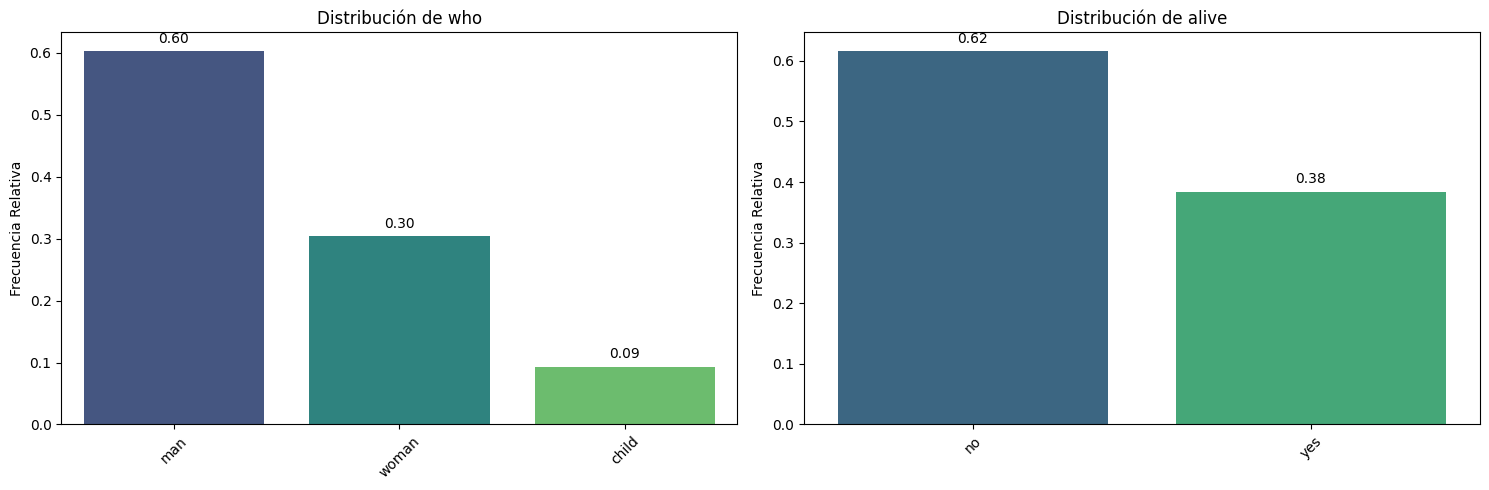

In [26]:
# analizamos cada una por separado
pinta_distribucion_categoricas(df,["who","alive"], relativa= True, mostrar_valores= True)

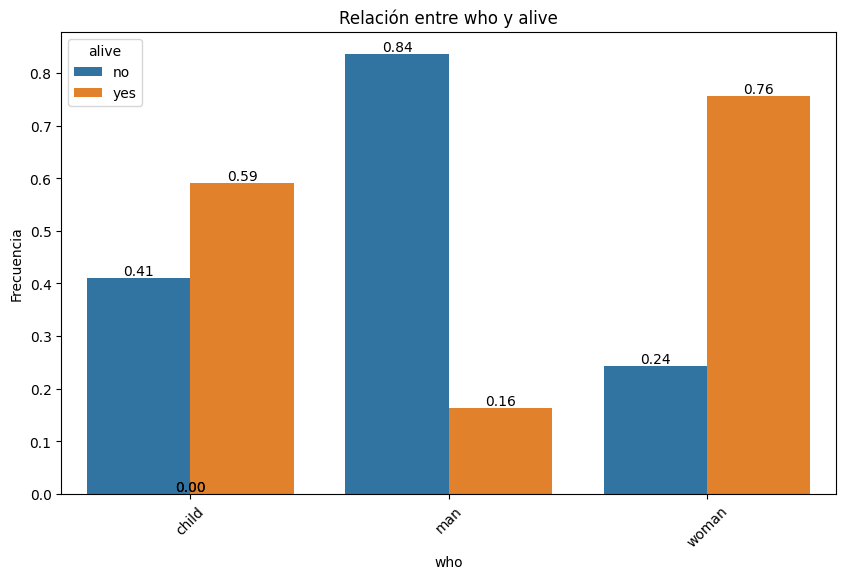

In [27]:
plot_categorical_relationship_fin(df, "who","alive", relative_freq = True, show_values = True)

In [33]:
from bootcampviztools import plot_combined_graphs, plot_grouped_histograms, plot_combined_graphs

(2,)


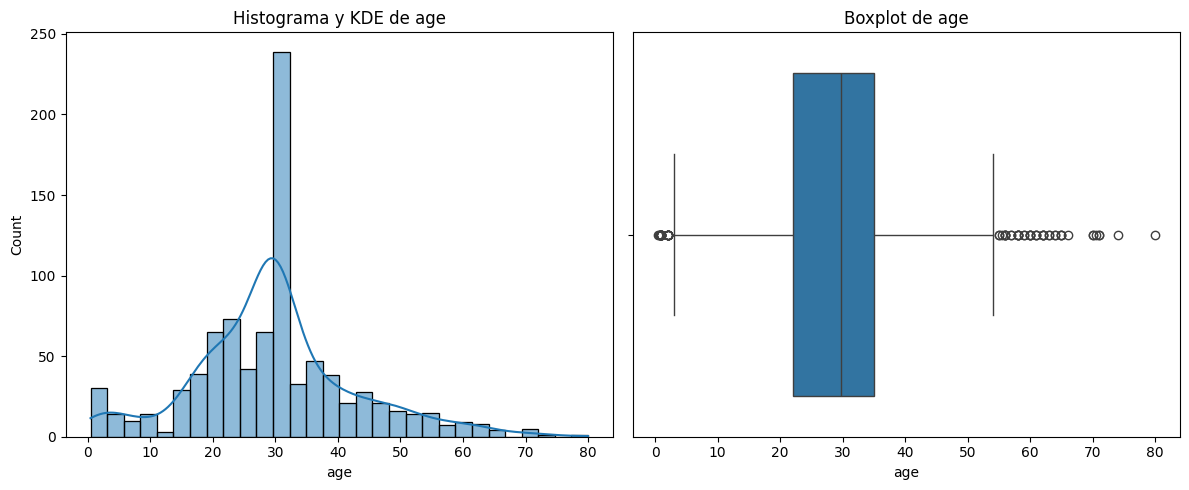

In [31]:
# analizamos alive - age (categorica-numerica)
# aunque primero vamos a mirar un poco la variable age
plot_combined_graphs(df,["age"])

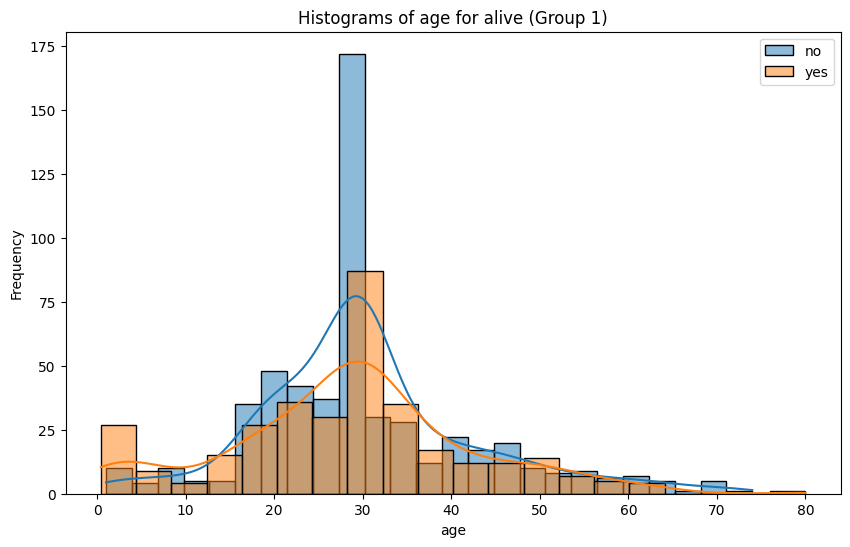

In [35]:
plot_grouped_histograms(df, cat_col="alive",num_col="age", group_size= 2)

In [37]:
# para who y alive, vamos a utilizar el método de chi cuadrado

tabla_contingencia = pd.crosstab(df['who'], df['alive'])

tabla_contingencia

from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(tabla_contingencia)


print("Valor Chi-Cuadrado:", chi2)
print("P-Value:", p)
print("Grados de Libertad:", dof)
print("Tabla de Frecuencias Esperadas:\n", expected)

Valor Chi-Cuadrado: 283.923050324233
P-Value: 2.2227620817798914e-62
Grados de Libertad: 2
Tabla de Frecuencias Esperadas:
 [[ 51.14141414  31.85858586]
 [330.87878788 206.12121212]
 [166.97979798 104.02020202]]


In [38]:
# Método de la prueba U de Mann-Whitney:

from scipy.stats import mannwhitneyu 

# Hipótesis nula, no existe relación entre las dos variables

#Separamos los datos en dos grupos según la variable categórica
grupo_a = df.loc[df.alive == "no"]["age"]
grupo_b = df.loc[df.alive == "yes"]["age"]

#Aplicamos la prueba y mostramos los resultados
u_stat, p_valor = mannwhitneyu(grupo_a, grupo_b)

print("Estadístico U:", u_stat)
print("Valor p:", p_valor)

#Si el resultado de p es mayor a 0.05 -- No hay evidencia estadística de rechazar la hipótesis nula
#Si el resultado de p es menor a 0.05 -- Hipóteis alternativa - Hay relación entre las dos variables que estamos analizando

Estadístico U: 98220.0
Valor p: 0.24336668156689534


In [39]:
# Existe una relación estadísticamente muy significativa entre el género (who) y la supervivencia en el Titanic.  
# Las mujeres y los niños sobrevivieron en mayor proporción que los hombres, y el test Chi‑cuadrado confirma esta asociación con un p‑value bajo.

# En cambio, la edad no muestra diferencias significativas entre sobrevivientes y fallecidos.  
# Las distribuciones de edad son similares y el test Mann‑Whitney arroja un p‑value > 0.05, por lo que no se puede afirmar
# que la edad influyera en la probabilidad de sobrevivir. 

2. En términos absolutos, ¿de que clase sobrevivieron más pasajeros?¿ Y en términos relativos? ¿Existe alguna relación estadísticamente significativa entre la clase en la que se viajaba y la supervivencia?

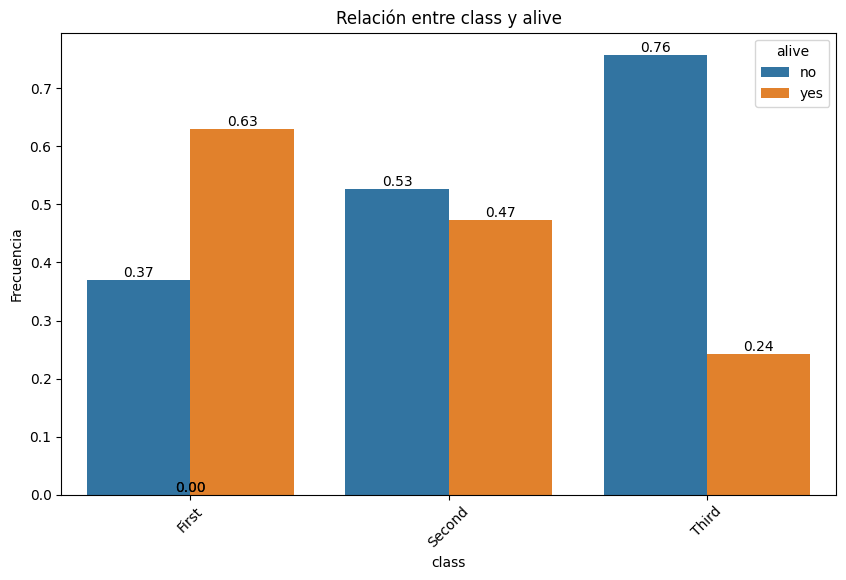

In [42]:
# variables a analizar "class" y "alive"
plot_categorical_relationship_fin(df, "class","alive", relative_freq = True, show_values = True)

In [43]:
# para class y alive, vamos a utilizar el método de chi cuadrado

tabla_contingencia = pd.crosstab(df['class'], df['alive'])

tabla_contingencia

from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(tabla_contingencia)


print("Valor Chi-Cuadrado:", chi2)
print("P-Value:", p)
print("Grados de Libertad:", dof)
print("Tabla de Frecuencias Esperadas:\n", expected)

Valor Chi-Cuadrado: 102.88898875696056
P-Value: 4.549251711298793e-23
Grados de Libertad: 2
Tabla de Frecuencias Esperadas:
 [[133.09090909  82.90909091]
 [113.37373737  70.62626263]
 [302.53535354 188.46464646]]


In [ ]:
# Conclusión, visualmente podemos ver que si están relacionadas, y el método chi-cuadrado nos da un valor muy bajo, por lo que podemos confirmar la hipótesis alternativa.


3. ¿De qué ciudad sobrevivieron más personas?¿Y porcentualmente de que ciudad sobrevivieron más personas? ¿Hay alguna relación estadística significativa entre haber embarcado en una de las tres ciudades y haber sobrevivido o fallecido?



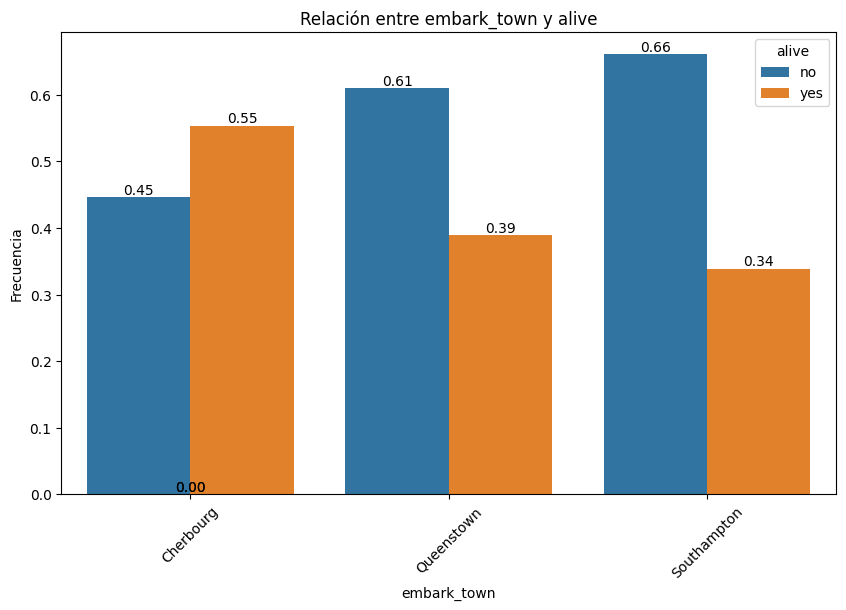

In [46]:
# alive (categorica binaria), embark_town (categorica)
plot_categorical_relationship_fin(df, "embark_town","alive", relative_freq = True, show_values = True)

In [47]:
# para embark_town y alive, vamos a utilizar el método de chi cuadrado

tabla_contingencia = pd.crosstab(df['embark_town'], df['alive'])

tabla_contingencia

from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(tabla_contingencia)


print("Valor Chi-Cuadrado:", chi2)
print("P-Value:", p)
print("Grados de Libertad:", dof)
print("Tabla de Frecuencias Esperadas:\n", expected)

Valor Chi-Cuadrado: 25.964452881874784
P-Value: 2.3008626481449577e-06
Grados de Libertad: 2
Tabla de Frecuencias Esperadas:
 [[103.51515152  64.48484848]
 [ 47.44444444  29.55555556]
 [398.04040404 247.95959596]]


In [ ]:
# Conclusión, están relacionadas, tanto visualmente como el p-value, al ser muy bajo, confirman la hipótesis alternativa que están relacionadas 
# murieron mas personas dependiendo del puerto de embarque, habría que estudiar si los puertos de embarque están relacionadas con la clase social

4. ¿Qué relación hay entre el precio del pasaje y la supervivencia/fallecimiento?

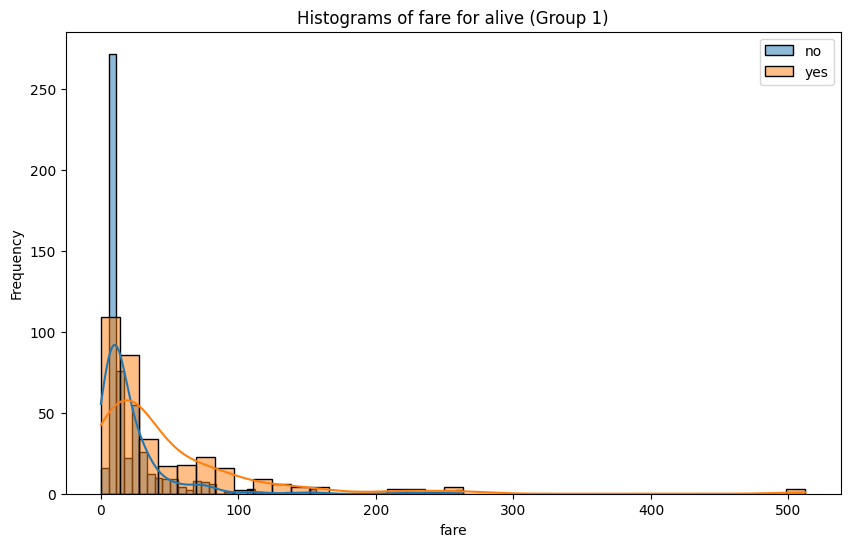

In [50]:
# fare variable numérica
# alive categorica binaria
plot_grouped_histograms(df, cat_col="alive",num_col="fare", group_size= 2)

In [53]:
# Método de la prueba U de Mann-Whitney: (categórica binaria, numérica)
variable_categorica = "alive"
valor_1_categorica = "yes"
valor_2_categorica = "no"
variable_numerica = "fare"
df_resultado = df
from scipy.stats import mannwhitneyu 

# Hipótesis nula, no existe relación entre las dos variables

#Separamos los datos en dos grupos según la variable categórica
grupo_a = df_resultado.loc[df_resultado[variable_categorica] == valor_1_categorica][variable_numerica]
grupo_b = df_resultado.loc[df_resultado[variable_categorica] == valor_2_categorica][variable_numerica]

#Aplicamos la prueba y mostramos los resultados
u_stat, p_valor = mannwhitneyu(grupo_a, grupo_b)

print("Estadístico U:", u_stat)
print("Valor p:", p_valor)

#Si el resultado de p es mayor a 0.05 -- No hay evidencia estadística de rechazar la hipótesis nula
#Si el resultado de p es menor a 0.05 -- Hipóteis alternativa - Hay relación entre las dos variables que estamos analizando

Estadístico U: 129951.5
Valor p: 4.553477179250237e-22


In [ ]:
# conclusión, visualmente y con el pvalue muy bajo, confirmamos la hipótesis alternativa, están relacionados el precio del pasaje (clase social) con la supervivencia


5. Existen pasajero que no pagaron el billete, ¿podrías explicar por qué? ¿Qué ocurrió con la persona que más dinero se dejó?


In [57]:
(df["fare"] == 0).sum()

np.int64(15)

In [ ]:
df[df["fare"] == 0]

,sex,age,fare,class,who,adult_male,embark_town,alive,alone,family_members
179,male,36.000000,0.0,Third,man,True,Southampton,no,True,0
263,male,40.000000,0.0,First,man,True,Southampton,no,True,0
271,male,25.000000,0.0,Third,man,True,Southampton,yes,True,0
277,male,29.699118,0.0,Second,man,True,Southampton,no,True,0
302,male,19.000000,0.0,Third,man,True,Southampton,no,True,0
413,male,29.699118,0.0,Second,man,True,Southampton,no,True,0
466,male,29.699118,0.0,Second,man,True,Southampton,no,True,0
481,male,29.699118,0.0,Second,man,True,Southampton,no,True,0
597,male,49.000000,0.0,Third,man,True,Southampton,no,True,0
633,male,29.699118,0.0,First,man,True,Southampton,no,True,0


6. Existe alguna relación entre el dinero pagado, la ciudad de embarque y la superviviencia/fallecimiento. No necesitas aplicar ningún test, muestralo numérica o visualmente.

In [63]:
from bootcampviztools import plot_grouped_boxplots

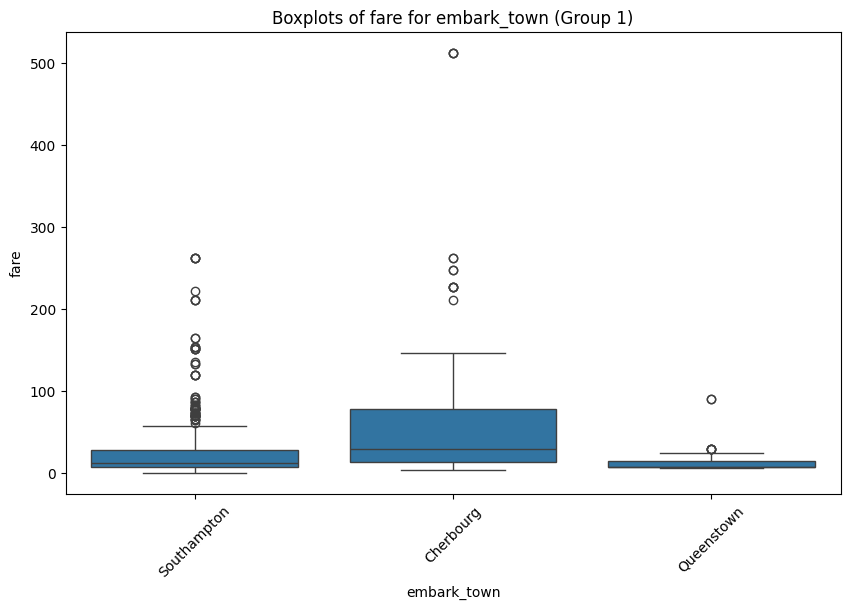

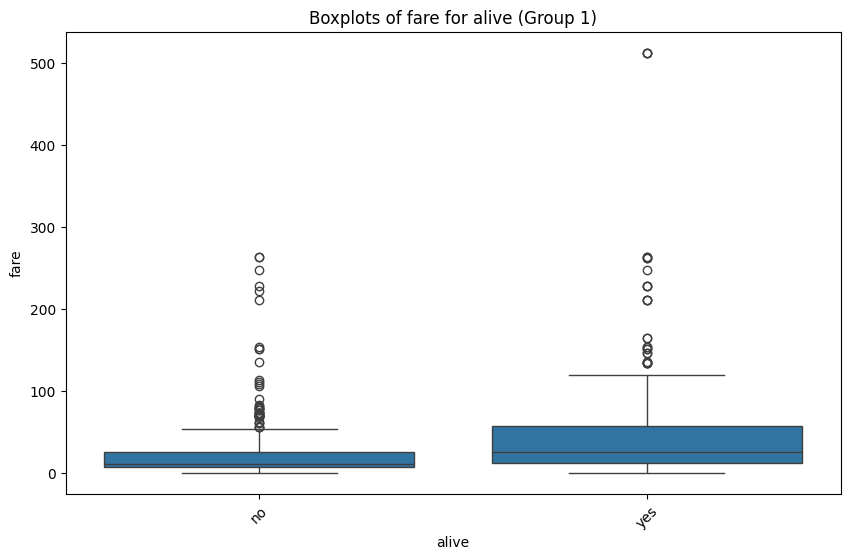

In [65]:
# fare - numérica
# embark_town - categorica
# alive - categorica binaria
plot_grouped_boxplots(df, "embark_town", "fare")
plot_grouped_boxplots(df, "alive", "fare")


In [ ]:
# Los billetes más caros fueron los de Cherbourg, seguidos por los de Queenstown, mientras que los más baratos fueron los de Southampton.
# Además, se observa que a mayor precio del billete, mayor porcentaje de supervivencia, lo que indica que los pasajeros de clases más altas 
# tuvieron más probabilidades de sobrevivir.

7. Ahondando en la relación entre sobrevivir o fallecer, la clase en la que se viajó y la edad de los pasajeros. ¿Qué agrupación de las dos variables (clase y edad) sobrevivió más en términos absolutos y en términos relativos?


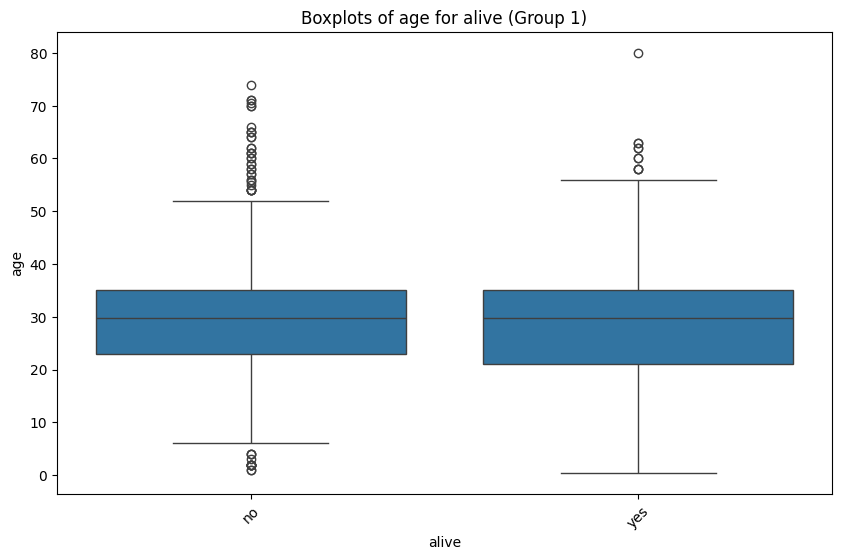

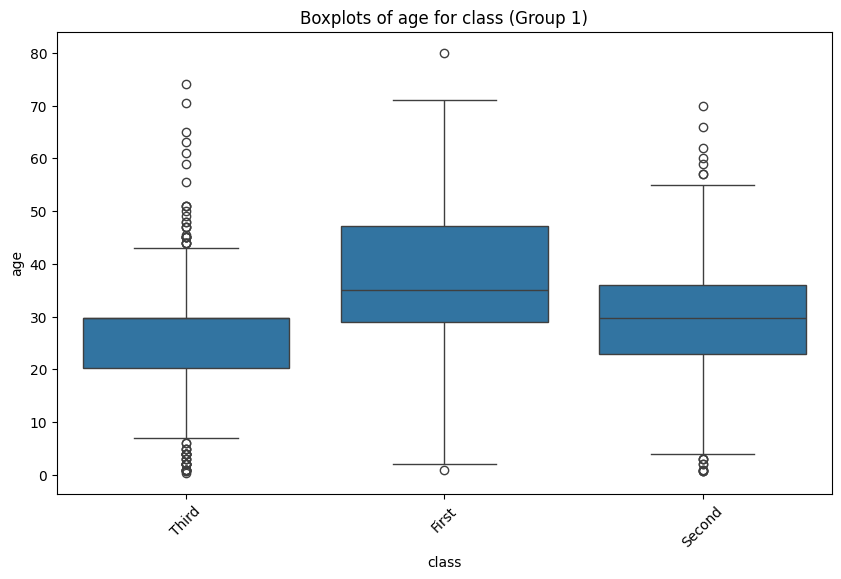

In [66]:
# alive - categorica binaria
# class - categorica
# age - numérica
plot_grouped_boxplots(df, "alive", "age")
plot_grouped_boxplots(df, "class", "age")


In [ ]:
# No se observa una relación clara entre la edad del pasajero y la supervivencia, ya que las distribuciones de edad entre quienes sobrevivieron y 
# quienes no lo hicieron son muy similares.

# En cambio, sí existe una relación entre la edad y la clase social: los pasajeros de mayor edad tienden a encontrarse en primera clase, 
# mientras que los más jóvenes predominan en tercera clase.

8. Finalmente, muestra las posibles relaciones entre edad, coste del billete y supervivencia/fallecimiento. ¿Qué puedes decir al respecto?

In [70]:
def scatter_plots_agrupados(df, col_categoria, col_num1, col_num2):
    """
    Genera scatter plots superpuestos de dos columnas numéricas, 
    agrupados y coloreados según una columna categórica.

    Args:
    df (pd.DataFrame): DataFrame que contiene los datos.
    col_categoria (str): Nombre de la columna categórica para agrupar y colorear los datos.
    col_num1 (str): Nombre de la primera columna numérica para el eje X.
    col_num2 (str): Nombre de la segunda columna numérica para el eje Y.
    """
    # Configuración para mejorar la estética del gráfico
    sns.set(style="whitegrid")

    plt.figure(figsize=(10, 8))

    # Usar seaborn para generar los scatter plots agrupados y coloreados
    sns.scatterplot(x=col_num1, y=col_num2, hue=col_categoria, data=df, palette="viridis")

    # Añadir título y etiquetas
    plt.title(f'Scatter Plots de {col_num1} vs {col_num2} Agrupados por {col_categoria}')
    plt.xlabel(col_num1)
    plt.ylabel(col_num2)

    # Mostrar leyenda y gráfico
    plt.legend(title=col_categoria)
    plt.show()


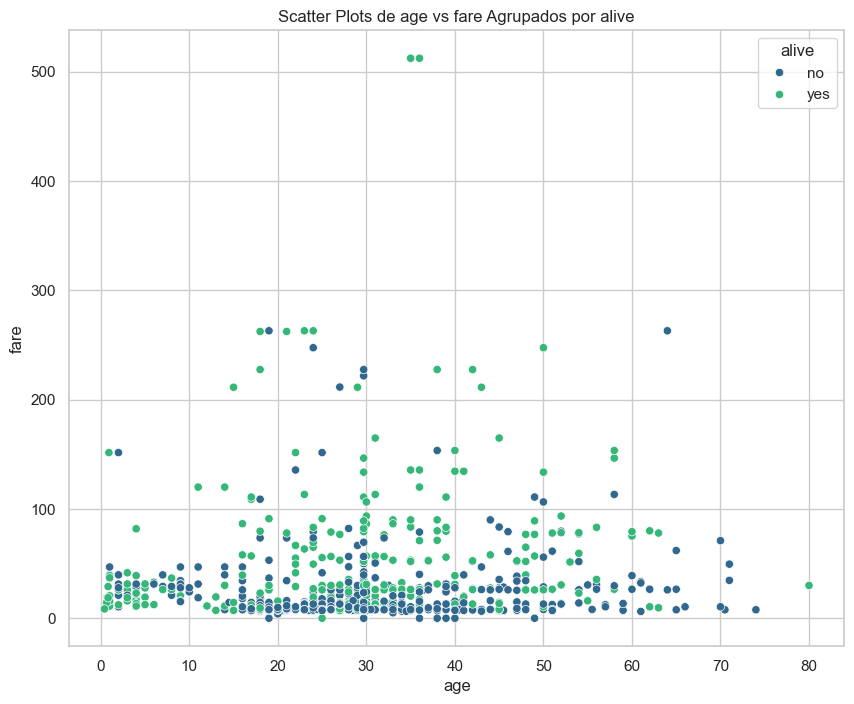

In [71]:
# age - numérica
# fare - numerica
# alive - categorica binaria


scatter_plots_agrupados(df, "alive", "age", "fare")


In [72]:
# No se observa una relación clara entre la edad del pasajero y el precio del billete, ya que los valores aparecen muy dispersos y sin tendencia definida.

# Sin embargo se aprecia que los pasajeros que sobrevivieron tienden a concentrarse en billetes más caros, independientemente de la edad.

# Por tanto, la edad no influye en el precio del billete, pero el precio del billete sí influye en la supervivencia

## #EXTRA: Viajes

El objetivo en este caso no es tanto hacer un montón de análisis sino de completar lo que quedó pendiente en el workout y de entender cómo de un dataset podemos obtener preguntas o hipótesis interesantes (si las hay)

### #EXTRA.1 

Carga el dataset de viajes del mes de junio. Repite el análisis bivariante entre las variables "Aircompany" e "Ingresos", mostrando previamente los viajes por compañía aérea. ¿Qué situación llamativa nos surgió? (Ten en cuenta que somos el departamenteo de DataScience de TabarAir)

In [74]:
df_air_jun = pd.read_csv("./data/dataset_viajes_jun.csv")
df_air_jun

,aircompany,origen,destino,distancia,avion,con_escala,consumo_kg,duracion,ingresos,id_vuelo,mes
0,Airnar,París,Ginebra,411,Boeing 737,False,1028.691900,51,14232.65,Air_PaGi_10737,Jun23
1,FlyQ,Bali,Roma,12738,Boeing 737,True,33479.132544,1167,468527.19,Fly_BaRo_10737,Jun23
2,TabarAir,Ginebra,Los Angeles,9103,Airbus A380,False,109439.907200,626,584789.19,Tab_GiLo_11380,Jun23
3,MoldaviAir,París,Cincinnati,6370,Boeing 737,False,17027.010000,503,233342.51,Mol_PaCi_10737,Jun23
4,TabarAir,Cincinnati,Roma,7480,Boeing 747,False,86115.744000,518,438535.07,Tab_CiRo_10747,Jun23
...,...,...,...,...,...,...,...,...,...,...,...
595,PamPangea,Bali,Londres,12553,Boeing 737,True,33310.138680,1153,442668.52,Pam_BaLo_10737,Jun23
596,Airnar,Cádiz,París,1447,Airbus A380,False,17229.139600,116,87307.63,Air_CaPa_11380,Jun23
597,Airnar,Los Angeles,Cádiz,9373,Boeing 737,False,23231.917800,731,339943.47,Air_LoCa_10737,Jun23
598,FlyQ,Barcelona,Bali,13058,Boeing 747,True,144766.211200,1070,752212.98,Fly_BaBa_10747,Jun23


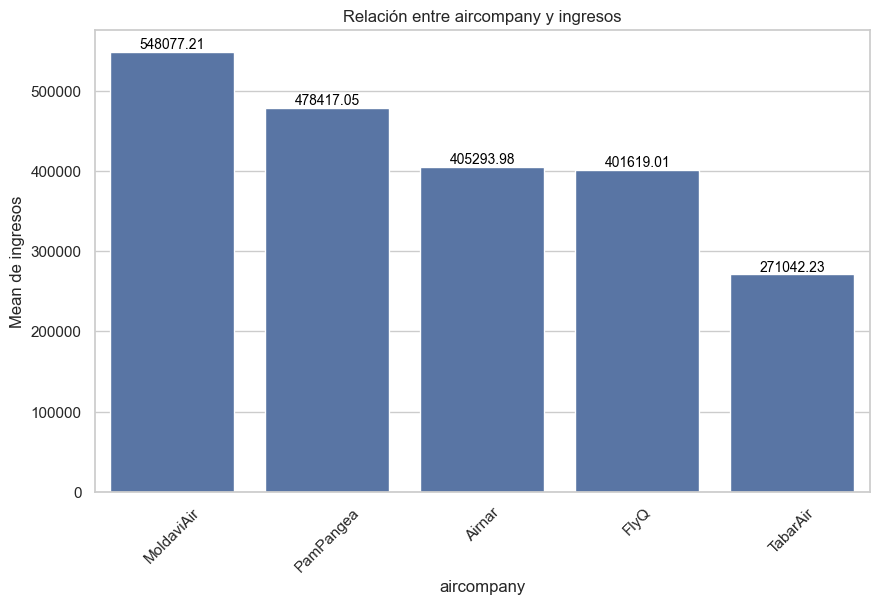

In [75]:
# la pregunta llamativa fue que la compañia TabarAir es la compañía que menos ingresos tiene
plot_categorical_numerical_relationship(df_air_jun, "aircompany", "ingresos", measure="mean", show_values=True)


### #EXTRA.2

Repite el análisis multivariante entre "ingresos","distancias" y "consumo_kg". ¿Qué veíamos que parecía también muy prometedor?

(3, 2)


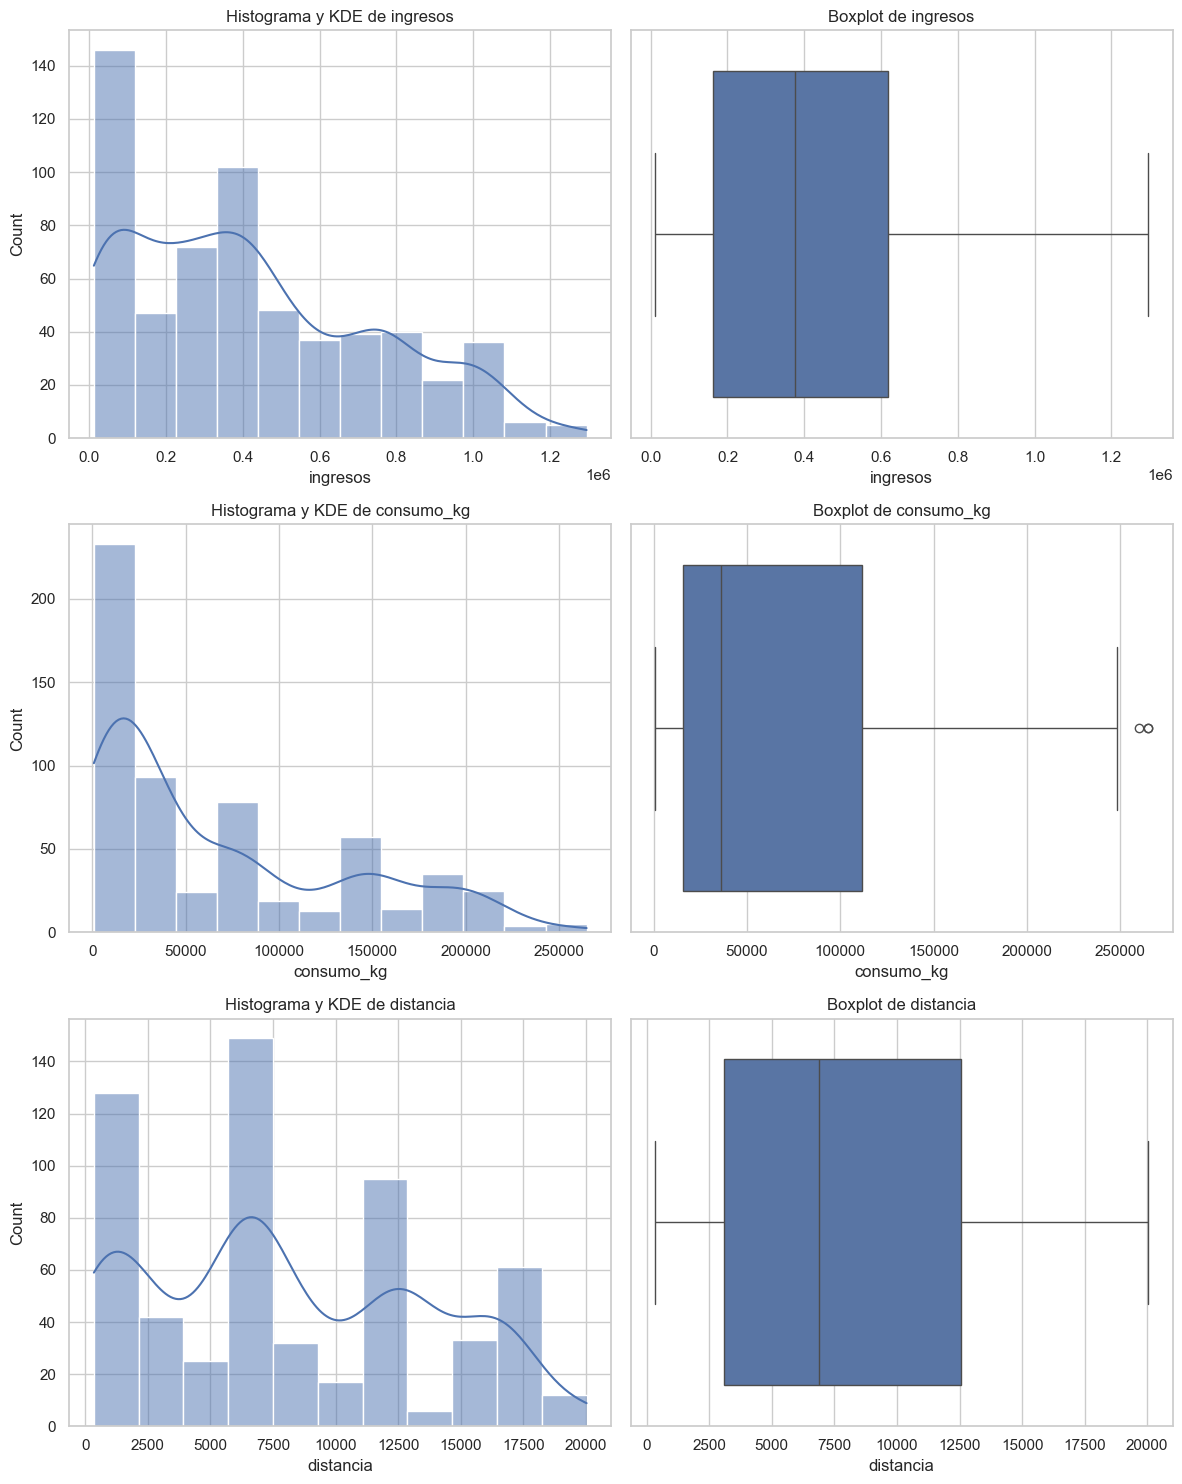

In [76]:
# ingresos - variable numérica
# distancias - variable numérica
# consumo - variable numérica
plot_combined_graphs(df_air_jun,["ingresos","consumo_kg","distancia"])

In [78]:
from bootcampviztools import bubble_plot

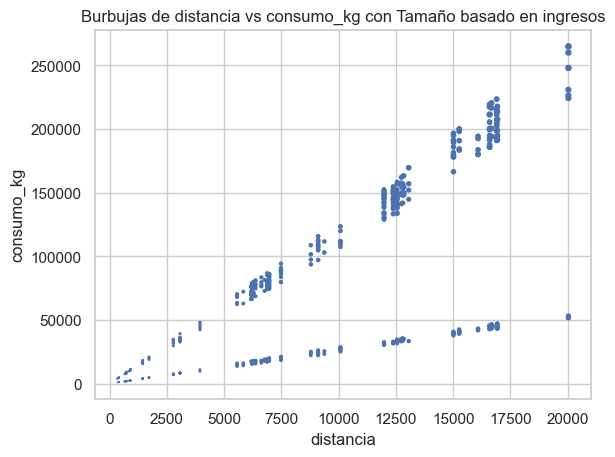

In [79]:
bubble_plot(df_air_jun,"distancia","consumo_kg","ingresos", scale = 100000)

### #EXTRA.3

Crea una variable categorica "cat_vuelo" a partir de distancias, escoge los rangos de las categorías basándote en la distribución de valores de "distancia" (sugerencia entre 3 y 4 categorías). Extra: Reaiza ahora otra vez el análisis multivariante "cat_vuelo", "ingresos", "consumo_kg". ¿Ves algo diferente?

In [81]:
df_air_jun["distancia"].describe()


count      600.000000
mean      8071.003333
std       5550.244086
min        344.000000
25%       3073.000000
50%       6877.000000
75%      12553.000000
max      20029.000000
Name: distancia, dtype: float64

In [83]:
def clasificador_apply(distancia):
    if distancia <= 3000:
        return "R"
    elif distancia <= 7000:
        return "MD"
    elif distancia <= 12500:
        return "LD"
    else:
        return "VLD"

df_air_jun["cat_vuelo"] = df_air_jun["distancia"].apply(clasificador_apply)

Categoría: R


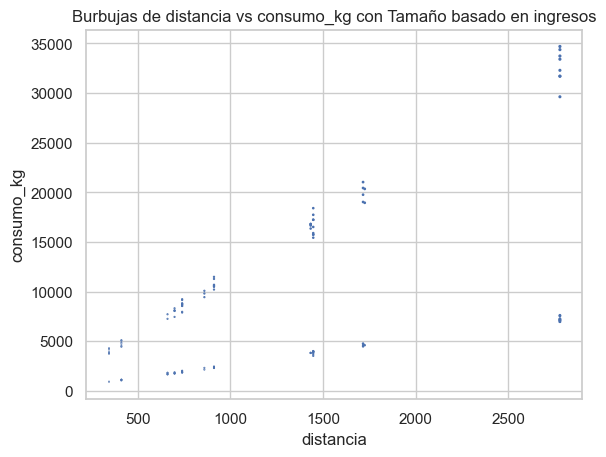

Categoría: VLD


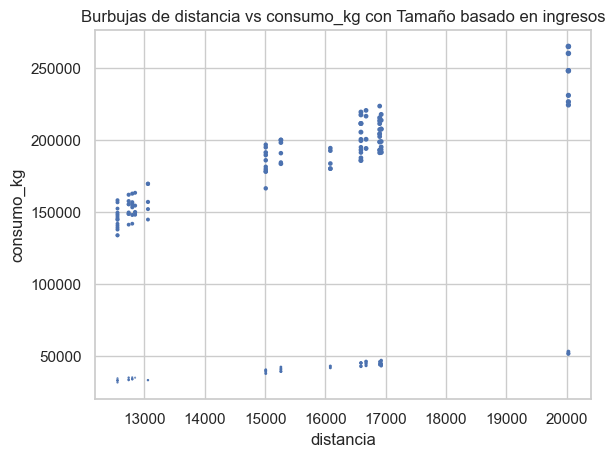

Categoría: LD


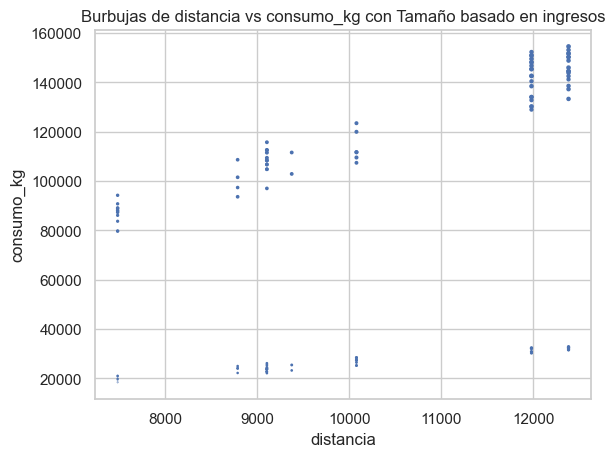

Categoría: MD


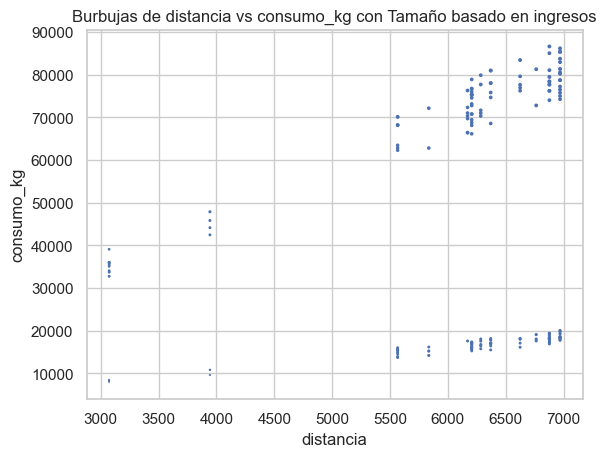

In [85]:
# cat_vuelo - categorica
# ingresos - numérica
# consumo - numérica
for cat in df_air_jun["cat_vuelo"].unique():
    print(f"Categoría: {cat}")
    bubble_plot(df_air_jun[df_air_jun["cat_vuelo"] == cat], "distancia", "consumo_kg", "ingresos", scale=100000)
